# Phase 3 - Step 10: Engagement Intelligence

This notebook analyzes enterprise engagement, calculates multi-factor composite engagement scores, evaluates departmental distributions, and identifies disengaged cohorts.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

processed_dir = Path("data/processed")
df_eng = pd.read_csv(processed_dir / "engagement_processed.csv")

# 1. Multi-factor Composite Engagement Score (0-100 scale)
df_eng['engagement_score'] = (
    0.25 * df_eng['attendance_pct'] +
    0.25 * df_eng['task_completion_pct'] +
    0.20 * df_eng['kpi_score'] +
    0.15 * (df_eng['peer_rating'] / 5.0 * 100.0) +
    0.15 * (df_eng['manager_feedback'] / 5.0 * 100.0)
).round(2)

# Engagement tiers
def get_engagement_tier(score):
    if score >= 85.0:
        return "Highly Engaged"
    elif score >= 75.0:
        return "Moderately Engaged"
    elif score >= 65.0:
        return "Passively Engaged"
    else:
        return "Disengaged / At Risk"

df_eng['engagement_tier'] = df_eng['engagement_score'].apply(get_engagement_tier)

print("=== OVERALL ENGAGEMENT SUMMARY ===")
print(f"Mean Engagement Score: {df_eng['engagement_score'].mean():.2f}")
print(f"Median Engagement Score: {df_eng['engagement_score'].median():.2f}")
print(f"Standard Deviation: {df_eng['engagement_score'].std():.2f}")
print("\nEngagement Tier Distribution:")
print(df_eng['engagement_tier'].value_counts(normalize=True) * 100)

print("\n=== DEPARTMENT-WISE ENGAGEMENT ===")
dept_summary = df_eng.groupby('department').agg(
    employee_count=('employee_id', 'count'),
    mean_engagement=('engagement_score', 'mean'),
    median_engagement=('engagement_score', 'median'),
    mean_kpi=('kpi_score', 'mean'),
    mean_attendance=('attendance_pct', 'mean'),
    mean_task_completion=('task_completion_pct', 'mean')
).round(2)
print(dept_summary)

# Save enriched engagement dataset
df_eng.to_csv(processed_dir / "engagement_processed.csv", index=False)
dept_summary.to_csv(processed_dir / "department_engagement_summary.csv")
print("Saved updated engagement data and department summary.")


=== OVERALL ENGAGEMENT SUMMARY ===
Mean Engagement Score: 82.59
Median Engagement Score: 82.60
Standard Deviation: 4.24

Engagement Tier Distribution:
engagement_tier
Moderately Engaged    66.56
Highly Engaged        29.82
Passively Engaged      3.62
Name: proportion, dtype: float64

=== DEPARTMENT-WISE ENGAGEMENT ===
            employee_count  mean_engagement  median_engagement  mean_kpi  \
department                                                                 
Finance               1016            82.56              82.68     77.39   
HR                    1010            82.66              82.74     77.66   
IT                     974            82.63              82.47     77.45   
Marketing              965            82.63              82.64     76.90   
Sales                 1035            82.49              82.40     77.50   

            mean_attendance  mean_task_completion  
department                                         
Finance               87.55                

C:\Users\User\AppData\Local\Temp\ipykernel_25256\3827567042.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='department', y='engagement_score', data=df_eng, palette='Blues')


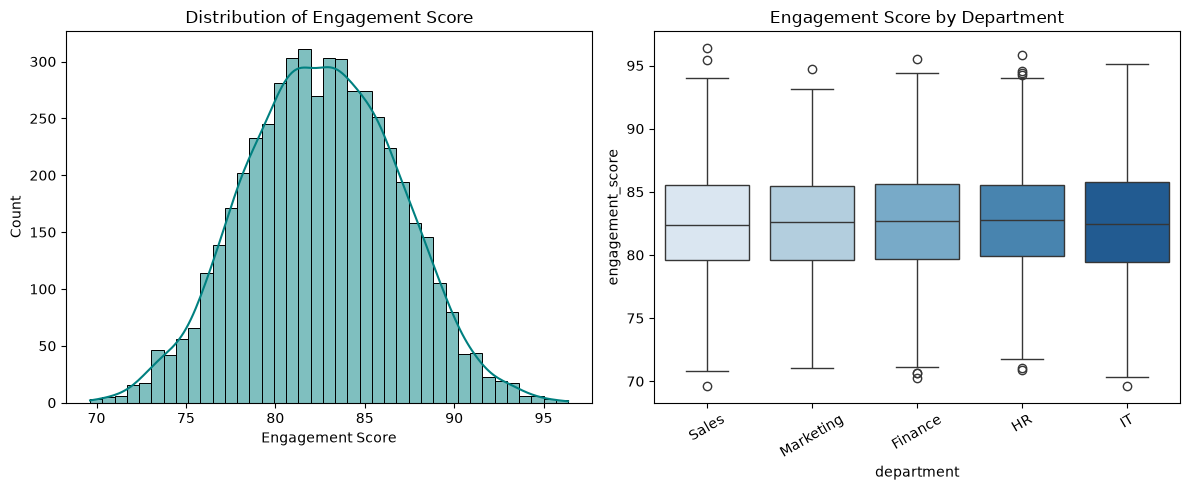

In [2]:
# Visualize Engagement
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_eng['engagement_score'], kde=True, color='teal')
plt.title("Distribution of Engagement Score")
plt.xlabel("Engagement Score")

plt.subplot(1, 2, 2)
sns.boxplot(x='department', y='engagement_score', data=df_eng, palette='Blues')
plt.title("Engagement Score by Department")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
